**Load the dataframe**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

base_path = '/content/drive/MyDrive/2025-2026 AIM Postgrad Diploma in AI & ML/Capstone Fraud Data Set/Train Data/'
train = pd.read_parquet(base_path + "train_transaction_identity.parquet")

for col in train.select_dtypes('float64').columns:
    train[col] = train[col].astype('float32')

print(train.shape)

Mounted at /content/drive
(590540, 434)


**Data Preprocessing, Applied EDA & Feature Engineering:**
Cleaning the dataset


In [ ]:
# 1. Duplicates
print("Exact duplicate rows:", train.duplicated().sum())

# 2. Nulls — capture the identity-join gap as a feature BEFORE dropping the id_ columns it explains
train['has_identity_data'] = train['DeviceType'].notna().astype(int)

# Drop columns >90% missing (per Step 2's Missingness Summary — not enough signal to impute meaningfully)
near_empty_cols = train.columns[train.isnull().mean() > 0.90].tolist()
print(f"\nDropping {len(near_empty_cols)} columns >90% missing:")
print(near_empty_cols)

train_clean = train.drop(columns=near_empty_cols)

# 3. Outliers — log-transform TransactionAmt rather than drop/cap, since Step 2 concluded the extremes
# are plausibly fraud signal, not noise (same logic likely applies to dist1/dist2 and the C/D/V outlier columns,
# but we'll revisit those once we see which features survive feature selection later in Step 3)
train_clean['TransactionAmt_log'] = np.log1p(train_clean['TransactionAmt'])

print("\nShape before cleaning:", train.shape)
print("Shape after cleaning:  ", train_clean.shape)

Exact duplicate rows: 0


/tmp/ipykernel_5432/1715465728.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['has_identity_data'] = train['DeviceType'].notna().astype(int)



Dropping 12 columns >90% missing:
['dist2', 'D7', 'id_07', 'id_08', 'id_18', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27']

Shape before cleaning: (590540, 435)
Shape after cleaning:   (590540, 424)


/tmp/ipykernel_5432/1715465728.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_clean['TransactionAmt_log'] = np.log1p(train_clean['TransactionAmt'])


**Data Preprocessing, Applied EDA & Feature Engineering:**
Feature engineering

In [ ]:
from sklearn.preprocessing import StandardScaler

# Domain-derived
train_clean['email_domain_match'] = (train_clean['P_emaildomain'] == train_clean['R_emaildomain']).astype(int)
train_clean['TransactionDT_day'] = train_clean['TransactionDT'] // 86400
train_clean['TransactionDT_hour'] = (train_clean['TransactionDT'] // 3600) % 24

# Binning
train_clean['hour_bucket'] = pd.cut(
    train_clean['TransactionDT_hour'], bins=[-1, 5, 11, 17, 23],
    labels=['late_night', 'morning', 'afternoon', 'evening']
)
train_clean['amount_tier'] = pd.qcut(train_clean['TransactionAmt_log'], q=4, labels=['low', 'mid', 'high', 'very_high'])

# Encoding
for col in ['card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain']:
    freq = train_clean[col].value_counts(normalize=True)
    train_clean[col + '_freq'] = train_clean[col].map(freq)

train_clean = pd.get_dummies(train_clean, columns=['ProductCD', 'card4', 'card6', 'DeviceType', 'hour_bucket', 'amount_tier'], dummy_na=True)

m_cols = [c for c in train_clean.columns if c.startswith('M') and c[1:].isdigit()]
for col in m_cols:
    train_clean[col] = train_clean[col].map({'T': 1, 'F': 0})

# Scaling (demonstration; full feature set scaled later, right before PCA)
scaler_demo = StandardScaler()
train_clean[['TransactionAmt_log_scaled', 'TransactionDT_hour_scaled']] = scaler_demo.fit_transform(
    train_clean[['TransactionAmt_log', 'TransactionDT_hour']]
)

print("Shape after feature engineering:", train_clean.shape)
print("\nNew columns added (sample):")
print([c for c in train_clean.columns if c not in train.columns][:15], "...")

/tmp/ipykernel_5432/134024828.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_clean['email_domain_match'] = (train_clean['P_emaildomain'] == train_clean['R_emaildomain']).astype(int)
/tmp/ipykernel_5432/134024828.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_clean['TransactionDT_day'] = train_clean['TransactionDT'] // 86400
/tmp/ipykernel_5432/134024828.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Con

Shape after feature engineering: (590540, 462)

New columns added (sample):
['TransactionAmt_log', 'email_domain_match', 'TransactionDT_day', 'TransactionDT_hour', 'card1_freq', 'card2_freq', 'card3_freq', 'card5_freq', 'addr1_freq', 'addr2_freq', 'P_emaildomain_freq', 'R_emaildomain_freq', 'ProductCD_C', 'ProductCD_H', 'ProductCD_R'] ...


**Data Preprocessing, Applied EDA & Feature Engineering:**
Applied Exploratory Data Analysis

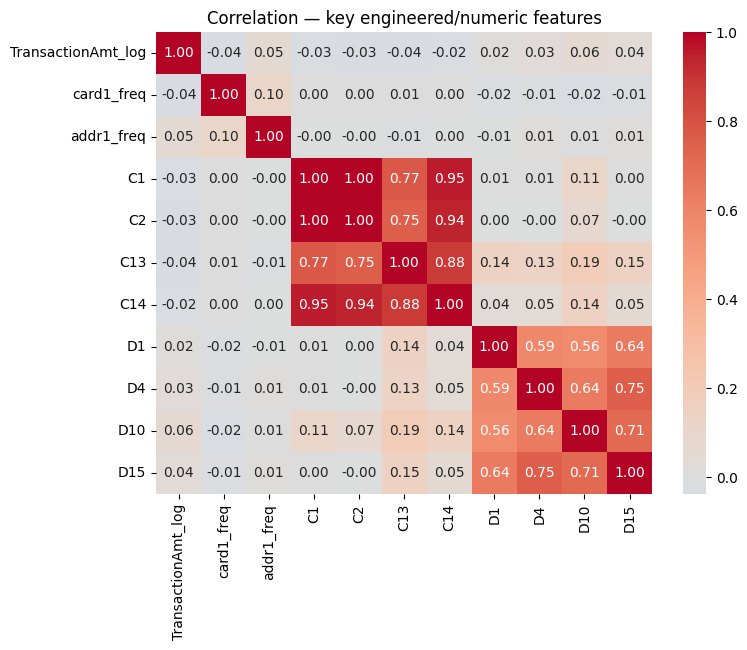

Hopkins statistic: 0.981  (~0.5 = random/no cluster structure, closer to 1 = clusterable)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# Relationships: correlation among key engineered/numeric features ---
numeric_sample_cols = [c for c in ['TransactionAmt_log', 'card1_freq', 'addr1_freq', 'C1', 'C2', 'C13', 'C14', 'D1', 'D4', 'D10', 'D15'] if c in train_clean.columns]
plt.figure(figsize=(8, 6))
sns.heatmap(train_clean[numeric_sample_cols].corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title("Correlation — key engineered/numeric features")
plt.show()

# Clustering tendency: Hopkins statistic ---
# H close to 1 = strong cluster structure, H close to 0.5 = random/uniform (no cluster structure)
def hopkins_statistic(X, m=None, random_state=42):
    rng = np.random.RandomState(random_state)
    n = X.shape[0]
    m = m or int(0.05 * n)
    nbrs = NearestNeighbors(n_neighbors=2).fit(X)
    idx = rng.choice(n, m, replace=False)
    u_dist, _ = nbrs.kneighbors(X[idx], n_neighbors=2)
    u_dist = u_dist[:, 1]
    rand_pts = rng.uniform(X.min(axis=0), X.max(axis=0), (m, X.shape[1]))
    w_dist, _ = nbrs.kneighbors(rand_pts, n_neighbors=1)
    return w_dist[:, 0].sum() / (u_dist.sum() + w_dist[:, 0].sum())

sample = train_clean[numeric_sample_cols].dropna().sample(5000, random_state=42)
h = hopkins_statistic(StandardScaler().fit_transform(sample))
print(f"Hopkins statistic: {h:.3f}  (~0.5 = random/no cluster structure, closer to 1 = clusterable)")

In [ ]:
# Robustness check: Hopkins statistic across multiple random samples ----
results = {}
for seed in [7, 21, 100, 2024, 55555]:
    sample_i = train_clean[numeric_sample_cols].dropna().sample(5000, random_state=seed)
    h_i = hopkins_statistic(StandardScaler().fit_transform(sample_i), random_state=seed)
    results[seed] = h_i
    print(f"random_state={seed:6d}  ->  Hopkins = {h_i:.3f}")

import numpy as np
vals = list(results.values())
print(f"\nMean: {np.mean(vals):.3f}   Std Dev: {np.std(vals):.3f}")

random_state=     7  ->  Hopkins = 0.974
random_state=    21  ->  Hopkins = 0.974
random_state=   100  ->  Hopkins = 0.971
random_state=  2024  ->  Hopkins = 0.970
random_state= 55555  ->  Hopkins = 0.982

Mean: 0.974   Std Dev: 0.004


**Data Preprocessing, Applied EDA & Feature Engineering:**
Feature Importance & Explainability

Top 20 features by model-based importance (fraud-correlation ranking):
V258    0.036591
V201    0.035807
C1      0.033475
V243    0.028897
V257    0.028323
V246    0.025124
C12     0.024746
V45     0.024527
V200    0.020043
V188    0.019261
V244    0.019159
C4      0.019011
V242    0.018790
V199    0.018580
V186    0.017666
V189    0.016430
C13     0.016018
C8      0.014777
V190    0.014347
C7      0.013335
dtype: float64


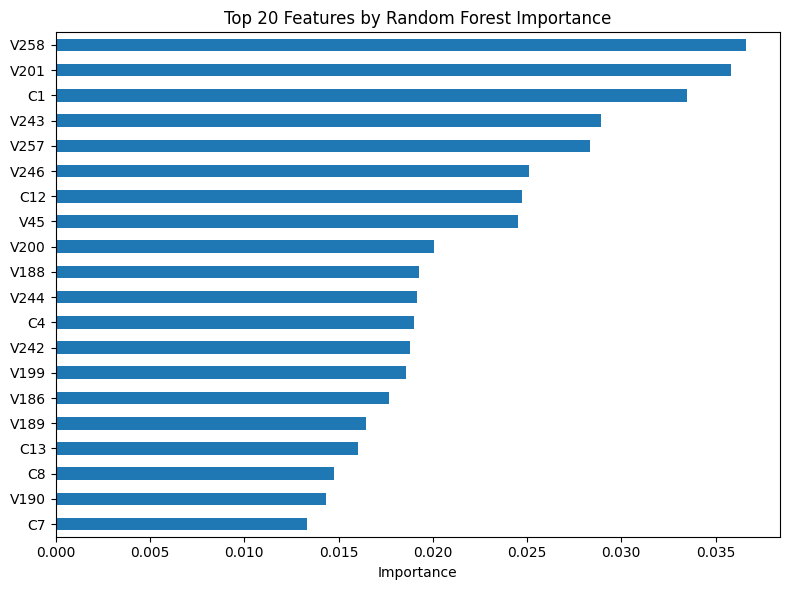

In [ ]:
from sklearn.ensemble import RandomForestClassifier

feature_cols = [c for c in train_clean.select_dtypes(include=[np.number]).columns
                if c not in ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt']]

X_imp = train_clean[feature_cols].fillna(-999)  # -999 flags "missing" distinctly, rather than 0 (a real value for many of these fields)
y_imp = train_clean['isFraud']

rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_imp, y_imp)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Top 20 features by model-based importance (fraud-correlation ranking):")
print(importances.head(20))

# Bar chart for the write-up
plt.figure(figsize=(8, 6))
importances.head(20).sort_values().plot(kind='barh')
plt.title("Top 20 Features by Random Forest Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

**Data Preprocessing, Applied EDA & Feature Engineering:**
Feature Selection

In [ ]:
import gc
from sklearn.feature_selection import VarianceThreshold
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# Re-define X_imp and y_imp from the previous step
feature_cols = [c for c in train_clean.select_dtypes(include=[np.number]).columns
                if c not in ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt']]

X_imp = train_clean[feature_cols].fillna(-999)  # -999 flags "missing" distinctly, rather than 0 (a real value for many of these fields)
y_imp = train_clean['isFraud']

# Free the Random Forest model now — only its importances (already saved) are needed downstream
if 'rf' in globals():
    del rf
    gc.collect()

# 1. Variance filter
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_imp)
low_var_cols = X_imp.columns[~selector.get_support()].tolist()
print(f"Dropping {len(low_var_cols)} near-zero-variance columns:")
print(low_var_cols)

X_var = X_imp.drop(columns=low_var_cols)
del X_imp, selector
gc.collect()

# 2. Correlation filter (on true values, not the -999-filled ones)
raw_for_corr = train_clean[X_var.columns]
corr = raw_for_corr.corr().abs()
del raw_for_corr
gc.collect()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_cols = [c for c in upper.columns if any(upper[c] > 0.95)]
print(f"\nDropping {len(high_corr_cols)} highly correlated (>0.95) columns:")
print(high_corr_cols)
del corr, upper
gc.collect()

final_features = X_var.drop(columns=high_corr_cols)
del X_var
gc.collect()

print("\nShape after feature selection:", final_features.shape)

Dropping 2 near-zero-variance columns:
['M4', 'card1_freq']

Dropping 140 highly correlated (>0.95) columns:
['C2', 'C4', 'C6', 'C8', 'C10', 'C11', 'C12', 'C14', 'D2', 'D6', 'D12', 'V11', 'V16', 'V18', 'V21', 'V22', 'V28', 'V30', 'V32', 'V33', 'V34', 'V43', 'V49', 'V50', 'V52', 'V57', 'V58', 'V60', 'V63', 'V70', 'V71', 'V72', 'V74', 'V81', 'V84', 'V89', 'V91', 'V92', 'V93', 'V94', 'V97', 'V101', 'V102', 'V103', 'V106', 'V126', 'V127', 'V128', 'V132', 'V133', 'V134', 'V143', 'V145', 'V149', 'V150', 'V151', 'V153', 'V154', 'V155', 'V156', 'V158', 'V159', 'V160', 'V163', 'V164', 'V167', 'V168', 'V177', 'V178', 'V179', 'V182', 'V192', 'V193', 'V196', 'V199', 'V202', 'V204', 'V206', 'V211', 'V212', 'V213', 'V217', 'V219', 'V222', 'V225', 'V231', 'V232', 'V233', 'V236', 'V237', 'V244', 'V249', 'V251', 'V253', 'V254', 'V256', 'V263', 'V265', 'V266', 'V269', 'V272', 'V273', 'V275', 'V276', 'V277', 'V278', 'V279', 'V280', 'V292', 'V293', 'V294', 'V295', 'V296', 'V298', 'V299', 'V304', 'V306', '

In [ ]:
# Memory cleanup before Dimensionality Reduction ----
import gc, psutil, os

def ram_gb():
    return psutil.Process(os.getpid()).memory_info().rss / 1024**3

print(f"RAM before cleanup: {ram_gb():.2f} GB")

float_cols = train_clean.select_dtypes('float64').columns
train_clean[float_cols] = train_clean[float_cols].astype('float32')

for var in ['train', 'X_imp', 'X_var', 'rf', 'corr', 'upper', 'raw_for_corr']:
    if var in globals():
        del globals()[var]

gc.collect()
print(f"RAM after cleanup:  {ram_gb():.2f} GB")

RAM before cleanup: 6.18 GB
RAM after cleanup:  6.18 GB


**Data Preprocessing, Applied EDA & Feature Engineering:**
Dimensionality reduction

PCA: 271 features -> 102 components (90% variance retained)


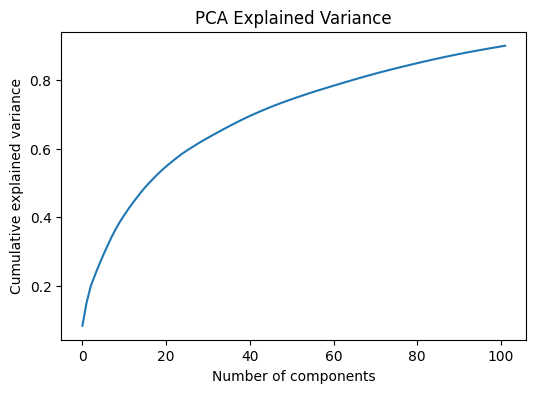

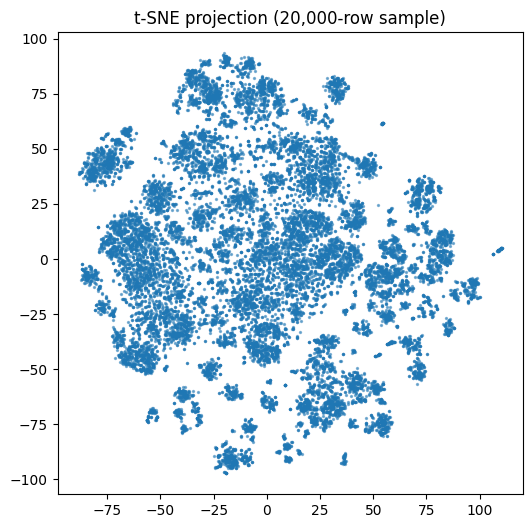

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import gc

# Re-impute the selected features properly for a variance-based method (median instead of -999)
final_raw = train_clean[final_features.columns]
final_imputed = final_raw.fillna(final_raw.median())

X_scaled = StandardScaler().fit_transform(final_imputed)

# PCA, keeping 90% of variance
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA: {X_scaled.shape[1]} features -> {X_pca.shape[1]} components (90% variance retained)")

plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance")
plt.show()

# Free large intermediates before the memory-heavy t-SNE step
del final_raw, final_imputed, X_scaled
gc.collect()

# t-SNE on a 20,000-row sample for 2D visualization (full-dataset t-SNE is too slow)
sample_idx = np.random.RandomState(42).choice(X_pca.shape[0], 20000, replace=False)
X_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_pca[sample_idx])

plt.figure(figsize=(6, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=2, alpha=0.5)
plt.title("t-SNE projection (20,000-row sample)")
plt.show()

**Model Implementation** K-Means (Elbow + Silhouette to pick k)

k=2: inertia=4137528.8, silhouette=0.842
k=3: inertia=3796631.7, silhouette=0.385
k=4: inertia=3603750.3, silhouette=0.380
k=5: inertia=3567007.6, silhouette=0.336
k=6: inertia=3389022.6, silhouette=0.060
k=7: inertia=3291274.7, silhouette=0.055
k=8: inertia=3246926.3, silhouette=0.064
k=9: inertia=3150378.5, silhouette=0.083
k=10: inertia=3093279.1, silhouette=0.052


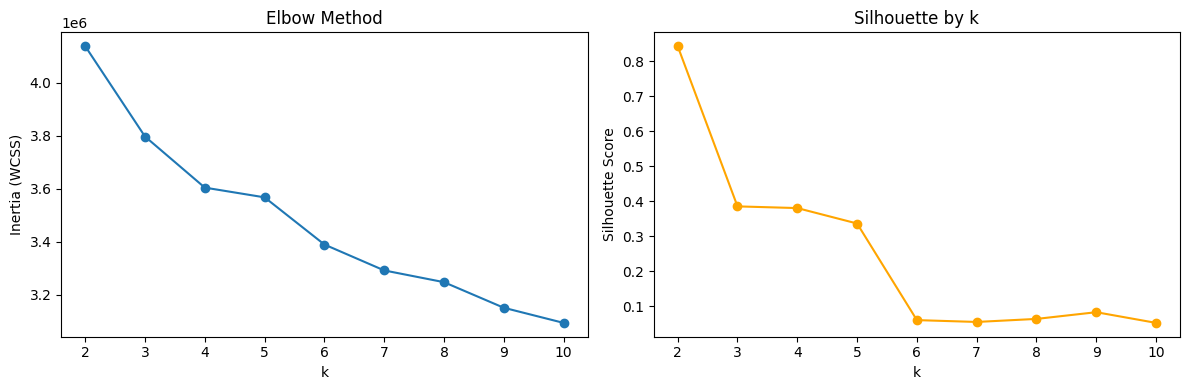

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Same sample used for t-SNE, for a fair, consistent comparison across all three models
sample_idx = np.random.RandomState(42).choice(X_pca.shape[0], 20000, replace=False)
X_cluster = X_pca[sample_idx]
y_cluster = train_clean['isFraud'].values[sample_idx]  # held out, used only for validation later

inertias, sil_scores = [], []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))
    print(f"k={k}: inertia={km.inertia_:.1f}, silhouette={sil_scores[-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia (WCSS)'); axes[0].set_title('Elbow Method')
axes[1].plot(list(k_range), sil_scores, marker='o', color='orange')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score'); axes[1].set_title('Silhouette by k')
plt.tight_layout()
plt.show()

In [ ]:
# K-Means: fraud-rate concentration check across candidate k values ----
import pandas as pd

base_rate = y_cluster.mean() * 100
print(f"Baseline fraud rate in this sample: {base_rate:.2f}%\n")

for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    df_check = pd.DataFrame({'cluster': labels, 'isFraud': y_cluster})
    fraud_by_cluster = df_check.groupby('cluster')['isFraud'].agg(['mean', 'count'])
    fraud_by_cluster['mean'] = (fraud_by_cluster['mean'] * 100).round(2)
    print(f"--- k={k} ---")
    print(fraud_by_cluster.rename(columns={'mean': 'fraud_rate_%', 'count': 'n_transactions'}))
    print()

Baseline fraud rate in this sample: 3.57%

--- k=2 ---
         fraud_rate_%  n_transactions
cluster                              
0                3.58           19944
1                0.00              56

--- k=3 ---
         fraud_rate_%  n_transactions
cluster                              
0                2.57           17711
1               11.58            2237
2                0.00              52

--- k=4 ---
         fraud_rate_%  n_transactions
cluster                              
0               11.60            2233
1                2.57           17712
2                0.00              52
3                0.00               3

--- k=5 ---
         fraud_rate_%  n_transactions
cluster                              
0                0.00              52
1                2.47           17558
2                8.86            2223
3               54.61             152
4                6.67              15



**Model Implementation** DBSCAN

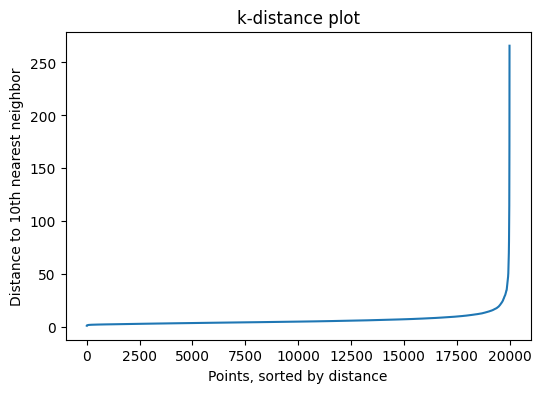

In [ ]:
from sklearn.neighbors import NearestNeighbors

min_samples = 10
neighbors = NearestNeighbors(n_neighbors=min_samples).fit(X_cluster)
distances, _ = neighbors.kneighbors(X_cluster)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(k_distances)
plt.xlabel("Points, sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.title("k-distance plot")
plt.show()

In [ ]:
# Auto-detect the knee point for eps
x = np.arange(len(k_distances))
x_norm = (x - x.min()) / (x.max() - x.min())
y_norm = (k_distances - k_distances.min()) / (k_distances.max() - k_distances.min())

dist_from_line = np.abs(y_norm - x_norm) / np.sqrt(2)
knee_idx = np.argmax(dist_from_line)
eps_suggestion = k_distances[knee_idx]

print(f"Knee point at index {knee_idx} of {len(k_distances)}")
print(f"Suggested eps: {eps_suggestion:.2f}")

Knee point at index 19402 of 20000
Suggested eps: 18.26


In [ ]:
# DBSCAN — fit and evaluate
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

dbscan_idx = np.random.RandomState(42).choice(X_cluster.shape[0], 10000, replace=False)
X_dbscan = X_cluster[dbscan_idx]
y_dbscan = y_cluster[dbscan_idx]

dbscan = DBSCAN(eps=18.26, min_samples=10, algorithm='ball_tree')
db_labels = dbscan.fit_predict(X_dbscan)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
print(f"Clusters found: {n_clusters}")
print(f"Noise points: {n_noise} ({n_noise / len(db_labels) * 100:.1f}%)")

mask = db_labels != -1
if n_clusters >= 2:
    print(f"Silhouette (excl. noise): {silhouette_score(X_dbscan[mask], db_labels[mask]):.3f}")
    print(f"Davies-Bouldin (excl. noise): {davies_bouldin_score(X_dbscan[mask], db_labels[mask]):.3f}")

df_check = pd.DataFrame({'cluster': db_labels, 'isFraud': y_dbscan})
fraud_by_cluster = df_check.groupby('cluster')['isFraud'].agg(['mean', 'count'])
fraud_by_cluster['mean'] = (fraud_by_cluster['mean'] * 100).round(2)
fraud_by_cluster = fraud_by_cluster.rename(columns={'mean': 'fraud_rate_%', 'count': 'n_transactions'})
print(f"\nBaseline fraud rate: {y_dbscan.mean()*100:.2f}%\n")
print(fraud_by_cluster.sort_values('fraud_rate_%', ascending=False))

Clusters found: 2
Noise points: 238 (2.4%)
Silhouette (excl. noise): 0.840
Davies-Bouldin (excl. noise): 0.251

Baseline fraud rate: 3.48%

         fraud_rate_%  n_transactions
cluster                              
-1              29.41             238
 0               2.85            9743
 1               0.00              19


**Model Implementation** Hierarchical

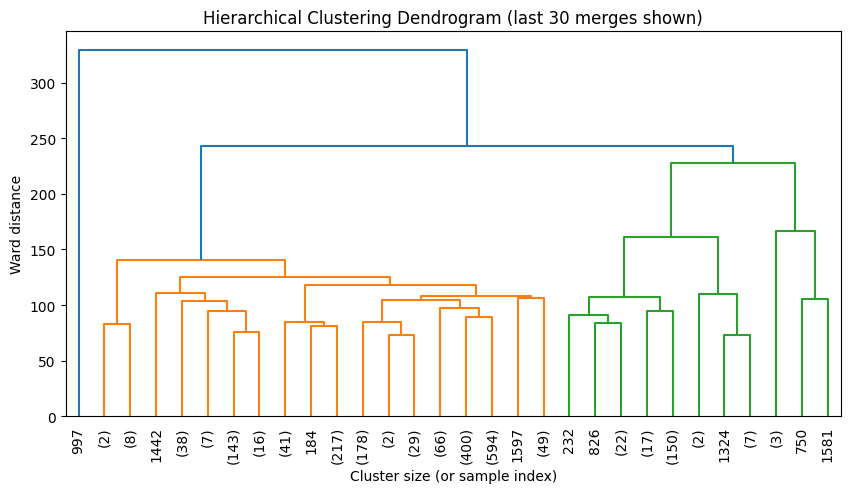

Suggested number of clusters (largest merge-distance jump): 2


In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Smaller sample: dendrograms need few enough leaves to be readable, and full linkage computation
# (which needs a full pairwise distance matrix) doesn't scale to tens of thousands of rows
hier_idx = np.random.RandomState(42).choice(X_cluster.shape[0], 2000, replace=False)
X_hier = X_cluster[hier_idx]
y_hier = y_cluster[hier_idx]

# Ward linkage: minimizes within-cluster variance, same objective as K-Means, standard choice for this kind of data
Z = linkage(X_hier, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (last 30 merges shown)")
plt.xlabel("Cluster size (or sample index)")
plt.ylabel("Ward distance")
plt.show()

# Auto-detect number of clusters: find the largest jump in the last 15 merge distances
last_merges = Z[-15:, 2]
merge_gaps = np.diff(last_merges)
best_gap_idx = np.argmax(merge_gaps)
n_clusters_suggestion = len(last_merges) - best_gap_idx
print(f"Suggested number of clusters (largest merge-distance jump): {n_clusters_suggestion}")

In [ ]:
# Hierarchical: fraud-rate concentration check across candidate cluster counts
from scipy.cluster.hierarchy import fcluster

print(f"Baseline fraud rate in this sample: {y_hier.mean()*100:.2f}%\n")

for k in [2, 3, 4, 5, 6]:
    labels = fcluster(Z, k, criterion='maxclust')
    df_check = pd.DataFrame({'cluster': labels, 'isFraud': y_hier})
    fraud_by_cluster = df_check.groupby('cluster')['isFraud'].agg(['mean', 'count'])
    fraud_by_cluster['mean'] = (fraud_by_cluster['mean'] * 100).round(2)
    print(f"--- k={k} ---")
    print(fraud_by_cluster.rename(columns={'mean': 'fraud_rate_%', 'count': 'n_transactions'}))
    print()

Baseline fraud rate in this sample: 3.70%

--- k=2 ---
         fraud_rate_%  n_transactions
cluster                              
1                 3.7            1999
2                 0.0               1

--- k=3 ---
         fraud_rate_%  n_transactions
cluster                              
1                2.90            1793
2               10.68             206
3                0.00               1

--- k=4 ---
         fraud_rate_%  n_transactions
cluster                              
1                2.90            1793
2               10.45             201
3               20.00               5
4                0.00               1

--- k=5 ---
         fraud_rate_%  n_transactions
cluster                              
1                2.90            1793
2               10.45             201
3                0.00               3
4               50.00               2
5                0.00               1

--- k=6 ---
         fraud_rate_%  n_transactions
cluster            

In [ ]:
# Hierarchical: internal metrics for k=3
from sklearn.metrics import silhouette_score, davies_bouldin_score

hier_labels = fcluster(Z, 3, criterion='maxclust')
print(f"Silhouette: {silhouette_score(X_hier, hier_labels):.3f}")
print(f"Davies-Bouldin: {davies_bouldin_score(X_hier, hier_labels):.3f}")

Silhouette: 0.392
Davies-Bouldin: 1.435


**Model Implementation** Model Comparison & Evaluation

In [ ]:
# Complete metrics for all three models
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

# K-Means (k=5) — full metrics
km_final = KMeans(n_clusters=5, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_cluster)
print("K-Means (k=5):")
print(f"  Silhouette: {silhouette_score(X_cluster, km_labels):.3f}")
print(f"  Davies-Bouldin: {davies_bouldin_score(X_cluster, km_labels):.3f}")
print(f"  Calinski-Harabasz: {calinski_harabasz_score(X_cluster, km_labels):.1f}")

# DBSCAN — add Calinski-Harabasz (excl. noise, same mask as before)
mask = db_labels != -1
print("\nDBSCAN:")
print(f"  Silhouette: {silhouette_score(X_dbscan[mask], db_labels[mask]):.3f}")
print(f"  Davies-Bouldin: {davies_bouldin_score(X_dbscan[mask], db_labels[mask]):.3f}")
print(f"  Calinski-Harabasz: {calinski_harabasz_score(X_dbscan[mask], db_labels[mask]):.1f}")

# Hierarchical (k=3) — add Calinski-Harabasz
print("\nHierarchical (k=3):")
print(f"  Silhouette: {silhouette_score(X_hier, hier_labels):.3f}")
print(f"  Davies-Bouldin: {davies_bouldin_score(X_hier, hier_labels):.3f}")
print(f"  Calinski-Harabasz: {calinski_harabasz_score(X_hier, hier_labels):.1f}")

K-Means (k=5):
  Silhouette: 0.336
  Davies-Bouldin: 1.662
  Calinski-Harabasz: 1298.6

DBSCAN:
  Silhouette: 0.840
  Davies-Bouldin: 0.251
  Calinski-Harabasz: 1224.2

Hierarchical (k=3):
  Silhouette: 0.392
  Davies-Bouldin: 1.435
  Calinski-Harabasz: 241.3


**Model Implementation** K-Means Validation

In [ ]:
# Strict validation: fit on 80%, validate on a held-out 20%
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Stratified split keeps both sides representative of the rare fraud class
X_train, X_holdout, y_train, y_holdout = train_test_split(
    X_cluster, y_cluster, test_size=0.2, random_state=42, stratify=y_cluster
)

# Fit K-Means ONLY on the training split
km_strict = KMeans(n_clusters=5, random_state=42, n_init=10)
train_labels = km_strict.fit_predict(X_train)

# Identify the highest-risk cluster using ONLY training data
fraud_cluster_label = pd.Series(y_train).groupby(train_labels).mean().idxmax()
train_fraud_rate = pd.Series(y_train).groupby(train_labels).mean()[fraud_cluster_label]
print(f"Highest-risk cluster (identified on training data): {fraud_cluster_label}")
print(f"Training-set fraud rate in that cluster: {train_fraud_rate*100:.2f}%")

# Assign holdout points to the nearest training-set cluster center (never seen during fitting)
holdout_labels = km_strict.predict(X_holdout)

# Check if the SAME cluster still concentrates fraud on data it never trained on
holdout_fraud_by_cluster = pd.Series(y_holdout).groupby(holdout_labels).agg(['mean', 'count'])
holdout_fraud_by_cluster['mean'] = (holdout_fraud_by_cluster['mean'] * 100).round(2)
print(f"\nHoldout baseline fraud rate: {y_holdout.mean()*100:.2f}%")
print(holdout_fraud_by_cluster.rename(columns={'mean': 'fraud_rate_%', 'count': 'n_transactions'}))

# Confusion matrix on the holdout set only
y_pred_holdout = (holdout_labels == fraud_cluster_label).astype(int)
tn, fp, fn, tp = confusion_matrix(y_holdout, y_pred_holdout).ravel()
print(f"\n--- Holdout Confusion Matrix ---")
print(f"True Positives (fraud caught):    {tp}")
print(f"False Positives (false alarms):  {fp}")
print(f"True Negatives:                  {tn}")
print(f"False Negatives (fraud missed):  {fn}")

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f"\nPrecision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")

Highest-risk cluster (identified on training data): 1
Training-set fraud rate in that cluster: 11.62%

Holdout baseline fraud rate: 3.57%
   fraud_rate_%  n_transactions
0          2.60            3538
1         11.49             444
2          0.00              15
3          0.00               1
4          0.00               2

--- Holdout Confusion Matrix ---
True Positives (fraud caught):    51
False Positives (false alarms):  393
True Negatives:                  3464
False Negatives (fraud missed):  92

Precision: 11.49%
Recall: 35.66%


**Model Implementation** DBSCAN Validation

In [ ]:
# Strict validation for DBSCAN: fit on 80%, validate on a held-out 20%
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import DBSCAN
from sklearn.metrics import confusion_matrix

# Stratified split of the DBSCAN sample
X_train_db, X_holdout_db, y_train_db, y_holdout_db = train_test_split(
    X_dbscan, y_dbscan, test_size=0.2, random_state=42, stratify=y_dbscan
)

# Fit DBSCAN only on the training split
dbscan_strict = DBSCAN(eps=18.26, min_samples=10, algorithm='ball_tree')
train_labels_db = dbscan_strict.fit_predict(X_train_db)
print(f"Training fraud rate in noise (-1): {y_train_db[train_labels_db == -1].mean()*100:.2f}%")

# DBSCAN has no native predict() — use KNN on the training points' DBSCAN labels
# (including -1 for noise) to assign holdout points to the nearest labeled group
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train_db, train_labels_db)
holdout_labels_db = knn.predict(X_holdout_db)

# Check if noise still concentrates fraud on data DBSCAN never saw
holdout_fraud_by_cluster = pd.Series(y_holdout_db).groupby(holdout_labels_db).agg(['mean', 'count'])
holdout_fraud_by_cluster['mean'] = (holdout_fraud_by_cluster['mean'] * 100).round(2)
print(f"\nHoldout baseline fraud rate: {y_holdout_db.mean()*100:.2f}%")
print(holdout_fraud_by_cluster.rename(columns={'mean': 'fraud_rate_%', 'count': 'n_transactions'}))

# Confusion matrix on holdout: noise (-1) = predicted fraud
y_pred_holdout_db = (holdout_labels_db == -1).astype(int)
tn, fp, fn, tp = confusion_matrix(y_holdout_db, y_pred_holdout_db).ravel()
print(f"\n--- Holdout Confusion Matrix (DBSCAN) ---")
print(f"True Positives (fraud caught):    {tp}")
print(f"False Positives (false alarms):  {fp}")
print(f"True Negatives:                  {tn}")
print(f"False Negatives (fraud missed):  {fn}")

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f"\nPrecision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")

Training fraud rate in noise (-1): 28.78%

Holdout baseline fraud rate: 3.50%
    fraud_rate_%  n_transactions
-1         34.78              23
 0          3.15            1971
 1          0.00               6

--- Holdout Confusion Matrix (DBSCAN) ---
True Positives (fraud caught):    8
False Positives (false alarms):  15
True Negatives:                  1915
False Negatives (fraud missed):  62

Precision: 34.78%
Recall: 11.43%


**Critical Thinking → Ethical AI & Bias Auditing** Explainability

In [ ]:
# Explainability — profile the high-risk cluster
km_final = KMeans(n_clusters=5, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_cluster)

fraud_cluster_label = pd.Series(y_cluster).groupby(km_labels).mean().idxmax()
high_risk_mask = (km_labels == fraud_cluster_label)

# Map back to original train_clean rows via sample_idx (X_cluster = X_pca[sample_idx])
high_risk_idx = sample_idx[high_risk_mask]
rest_idx = sample_idx[~high_risk_mask]

# Continuous features
continuous_cols = ['TransactionAmt', 'TransactionAmt_log', 'TransactionDT_hour', 'card1_freq', 'addr1_freq']
continuous_cols = [c for c in continuous_cols if c in train_clean.columns]

high_risk_cont = train_clean.iloc[high_risk_idx][continuous_cols].mean()
rest_cont = train_clean.iloc[rest_idx][continuous_cols].mean()
cont_comparison = pd.DataFrame({'high_risk_cluster': high_risk_cont, 'rest_of_sample': rest_cont})
cont_comparison['ratio'] = (cont_comparison['high_risk_cluster'] / cont_comparison['rest_of_sample']).round(2)
print("Continuous feature comparison:")
print(cont_comparison)

# Categorical (one-hot dummy) features — mean of a 0/1 column = proportion in that category
dummy_prefixes = ['ProductCD_', 'card4_', 'card6_', 'DeviceType_', 'hour_bucket_', 'amount_tier_']
dummy_cols = [c for c in train_clean.columns if any(c.startswith(p) for p in dummy_prefixes)]

high_risk_dummy = train_clean.iloc[high_risk_idx][dummy_cols].mean()
rest_dummy = train_clean.iloc[rest_idx][dummy_cols].mean()
dummy_comparison = pd.DataFrame({'high_risk_%': (high_risk_dummy*100).round(1), 'rest_%': (rest_dummy*100).round(1)})
dummy_comparison['difference_pp'] = (dummy_comparison['high_risk_%'] - dummy_comparison['rest_%']).round(1)
print("\nCategorical feature comparison (% of cluster in each category):")
print(dummy_comparison.sort_values('difference_pp', key=abs, ascending=False).head(15))

Continuous feature comparison:
                    high_risk_cluster  rest_of_sample  ratio
TransactionAmt             114.426643      134.019226   0.85
TransactionAmt_log           4.051989        4.384484   0.92
TransactionDT_hour          12.427632       13.938432   0.89
card1_freq                   0.003269        0.004255   0.77
addr1_freq                   0.043731        0.042969   1.02

Categorical feature comparison (% of cluster in each category):
                        high_risk_%  rest_%  difference_pp
DeviceType_nan                  1.3    76.5          -75.2
ProductCD_W                     0.0    74.8          -74.8
DeviceType_desktop             76.3    14.2           62.1
ProductCD_C                    70.4    11.4           59.0
card6_credit                   48.0    25.0           23.0
card6_debit                    52.0    74.7          -22.7
amount_tier_low                45.4    24.7           20.7
ProductCD_R                    19.7     6.1           13.6
DeviceT

In [ ]:
# Step 5: Bias & Fairness Audit — flagging rate across regions (addr1)
# No demographic fields exist in this anonymized dataset, so addr1 (billing region code) is used as the best available proxy for a "sensitive group."

df_fair = pd.DataFrame({
    'addr1': train_clean.iloc[sample_idx]['addr1'].values,
    'high_risk': high_risk_mask.astype(int),
    'isFraud': y_cluster
})

# Focus on the top 10 most common regions — smaller regions have too few transactions for a stable estimate
top_regions = df_fair['addr1'].value_counts().head(10).index
df_fair_top = df_fair[df_fair['addr1'].isin(top_regions)]

region_stats = df_fair_top.groupby('addr1').apply(lambda g: pd.Series({
    'n_transactions': len(g),
    'actual_fraud_rate_%': round(g['isFraud'].mean() * 100, 2),
    'flagged_rate_%': round(g['high_risk'].mean() * 100, 2),
    'precision_within_region_%': round(g.loc[g['high_risk'] == 1, 'isFraud'].mean() * 100, 2) if g['high_risk'].sum() > 0 else 0
}))

print(region_stats.sort_values('flagged_rate_%', ascending=False))

# Disparate impact check (four-fifths rule): each region's flagged rate vs. the highest-flagged region
max_flag_rate = region_stats['flagged_rate_%'].max()
region_stats['disparate_impact_ratio'] = (region_stats['flagged_rate_%'] / max_flag_rate).round(2)
print("\nRegions below the 0.8 disparate impact threshold (four-fifths rule):")
print(region_stats[region_stats['disparate_impact_ratio'] < 0.8])

       n_transactions  actual_fraud_rate_%  flagged_rate_%  \
addr1                                                        
299.0          1623.0                 2.77            0.43   
184.0           541.0                 1.48            0.37   
204.0          1405.0                 3.20            0.36   
272.0           670.0                 2.99            0.30   
441.0           670.0                 2.69            0.30   
315.0           803.0                 2.24            0.25   
325.0          1467.0                 2.25            0.20   
264.0          1315.0                 2.13            0.15   
123.0           539.0                 2.97            0.00   
330.0           859.0                 3.49            0.00   

       precision_within_region_%  
addr1                             
299.0                      57.14  
184.0                       0.00  
204.0                      40.00  
272.0                     100.00  
441.0                     100.00  
315.0     

/tmp/ipykernel_5432/2424897222.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  region_stats = df_fair_top.groupby('addr1').apply(lambda g: pd.Series({


**Save final models**

In [ ]:
import joblib
import os

os.makedirs(base_path + 'models', exist_ok=True)
joblib.dump(km_final, base_path + 'models/kmeans_k5.joblib')
joblib.dump(dbscan, base_path + 'models/dbscan_eps18_26.joblib')
print("Models saved to:", base_path + 'models')

Models saved to: /content/drive/MyDrive/2025-2026 AIM Postgrad Diploma in AI & ML/Capstone Fraud Data Set/Train Data/models
